In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

In [3]:
df = pd.read_csv("/content/archive (12).zip")

In [4]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [6]:
df['AVG_marks']= (df['math score']+df['reading score']+df['writing score'])/3


In [7]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,AVG_marks
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667
1,female,group C,some college,standard,completed,69,90,88,82.333333
2,female,group B,master's degree,standard,none,90,95,93,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333
4,male,group C,some college,standard,none,76,78,75,76.333333


In [8]:
def category(avg_marks):
  if avg_marks >= 80:
    return 'Level A'
  elif avg_marks >= 70:
    return 'Level B'
  else:
    return 'Level C'

df['level'] = df['AVG_marks'].apply(category)


In [9]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,AVG_marks,level
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667,Level B
1,female,group C,some college,standard,completed,69,90,88,82.333333,Level A
2,female,group B,master's degree,standard,none,90,95,93,92.666667,Level A
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333,Level C
4,male,group C,some college,standard,none,76,78,75,76.333333,Level B


In [11]:
X = df[["math score", "reading score", "writing score"]]
y = df["level"]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [13]:
model = SVC(kernel="linear")
model.fit(X_train, y_train)

SVC(kernel='linear')

In [14]:
y_pred = model.predict(X_test)

In [15]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

     Level A       1.00      1.00      1.00        31
     Level B       1.00      1.00      1.00        59
     Level C       1.00      1.00      1.00       110

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [17]:
new_student = [[60, 65, 66]]

prediction = model.predict(new_student)

print("Predicted Level:", prediction[0])

Predicted Level: Level C


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


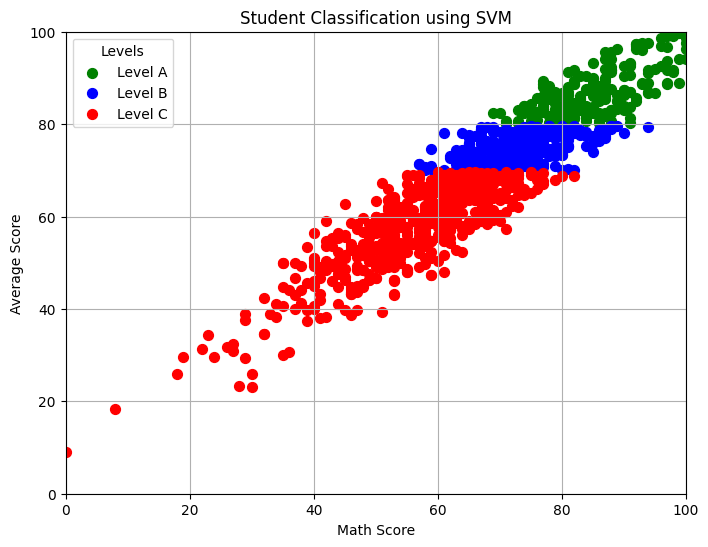

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))


plt.scatter(
    df[df["level"]=="Level A"]["math score"],
    df[df["level"]=="Level A"]["AVG_marks"],
    color="green",
    label="Level A",
    s=50
)


plt.scatter(
    df[df["level"]=="Level B"]["math score"],
    df[df["level"]=="Level B"]["AVG_marks"],
    color="blue",
    label="Level B",
    s=50
)


plt.scatter(
    df[df["level"]=="Level C"]["math score"],
    df[df["level"]=="Level C"]["AVG_marks"],
    color="red",
    label="Level C",
    s=50
)

plt.title("Student Classification using SVM")
plt.xlabel("Math Score")
plt.ylabel("Average Score")
plt.legend(title="Levels")
plt.grid(True)
plt.xlim(0,100)
plt.ylim(0,100)

plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


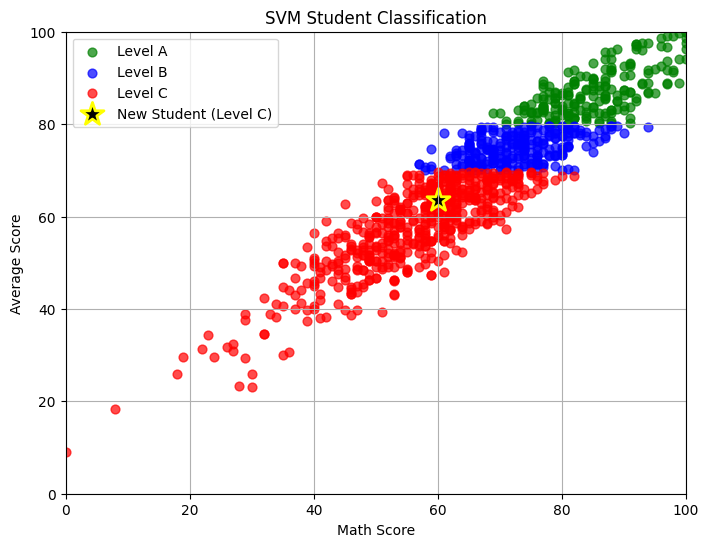

Predicted Level: Level C


In [25]:
new_student = [[60, 65, 66]]
prediction = model.predict(new_student)[0]

avg = sum(new_student[0]) / 3

colors = {
    "Level A": "green",
    "Level B": "blue",
    "Level C": "red"
}

plt.figure(figsize=(8,6))


for level, color in colors.items():
    subset = df[df["level"] == level]
    plt.scatter(
        subset["math score"],
        subset["AVG_marks"],
        color=color,
        label=level,
        s=40,
        alpha=0.7
    )

plt.scatter(
    new_student[0][0],
    avg,
    color="black",
    marker="*",
    s=300,
    edgecolors="yellow",
    linewidths=2,
    label=f"New Student ({prediction})"
)

plt.title("SVM Student Classification")
plt.xlabel("Math Score")
plt.ylabel("Average Score")
plt.legend()
plt.grid(True)
plt.xlim(0,100)
plt.ylim(0,100)

plt.show()

print("Predicted Level:", prediction)